In [2]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:18px;}
</style>
"""))

In [3]:
# # GPU 활성화 끄기
# import os
# os.environ['CUDA_VISIBLE_DEVICES'] = "-1"
# GPU 사용 여부 확인
import tensorflow as tf
print(tf.__version__)
tf.config.list_physical_devices('GPU')

2.10.0


[]

# 1. 기존의 프로그램 방식

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# 섭씨온도(input data)를 받아 화씨 온도로 출력
def celsius_to_faherenheit(c):
    return 1.8*c + 32

In [8]:
input_data = int(input('섭씨온도는? '))
print('화씨온도는 ', celsius_to_faherenheit(input_data))

섭씨온도는? 0
화씨온도는  32.0


# 2. 머신러닝/딥러닝 프로그램 방식
- 1. 데이터 확보 및 생성
- 2. 데이터 전처리 : scale조정, 라벨링처리, 훈련데이터셋(학습데이터셋), 검증데이터셋, 시험데이터셋으로 나누기
- 3. 모델구성
- 4. 모델 학습과정 설정
- 5. 모델 학습시키기(학습데이터셋과 검증데이터셋으로)
- 6. 모델 평가(시험데이터셋으로)
- 7. 모델 사용(입력값이 주어지면 예측값을 받기)

## 2.1 노이즈가 없는 데이터로 실습

In [9]:
# 1. 데이터 생성
data_C = np.arange(100)
data_C # 입력변수==독립변수

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [10]:
data_F = celsius_to_faherenheit(data_C)
data_F # 타겟변수==종속변수

array([ 32. ,  33.8,  35.6,  37.4,  39.2,  41. ,  42.8,  44.6,  46.4,
        48.2,  50. ,  51.8,  53.6,  55.4,  57.2,  59. ,  60.8,  62.6,
        64.4,  66.2,  68. ,  69.8,  71.6,  73.4,  75.2,  77. ,  78.8,
        80.6,  82.4,  84.2,  86. ,  87.8,  89.6,  91.4,  93.2,  95. ,
        96.8,  98.6, 100.4, 102.2, 104. , 105.8, 107.6, 109.4, 111.2,
       113. , 114.8, 116.6, 118.4, 120.2, 122. , 123.8, 125.6, 127.4,
       129.2, 131. , 132.8, 134.6, 136.4, 138.2, 140. , 141.8, 143.6,
       145.4, 147.2, 149. , 150.8, 152.6, 154.4, 156.2, 158. , 159.8,
       161.6, 163.4, 165.2, 167. , 168.8, 170.6, 172.4, 174.2, 176. ,
       177.8, 179.6, 181.4, 183.2, 185. , 186.8, 188.6, 190.4, 192.2,
       194. , 195.8, 197.6, 199.4, 201.2, 203. , 204.8, 206.6, 208.4,
       210.2])

In [13]:
# 2. 데이터 전처리 : 컴퓨터에게 학습시키기 위해, normalize함 (변수들의 편차를 비슷하게)
scaled_data_C = data_C/100.0
scaled_data_F = data_F/100.0
print('독립변수는 ', scaled_data_C)
print('종속변수는 ', scaled_data_F)

독립변수  [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]


In [14]:
# 3. 모델 구성(tensorflow)
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense # 입력값과 출력값으로 layer층 지정
model = Sequential()
model.add(Dense(1, # 출력(종속, 타겟)변수의 갯수
                input_shape=(1, ) # 입력(독립)변수의 shape
               ))
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________
None


# 회귀분석 오차함수 : MSE(오차제곱평균), 

- 회귀분석 오차함수 : MSE(오차제곱평균),RMSE(루트를 취하기 때문에 MSC단점이 어느정도 해소. 덜 민감), MAE(절대값평균)

In [15]:
# 4. 모델 학습 과정 설정
model.compile(loss='mse', optimizer='rmsprop', metrics=['mae'])
              # 손실함수        옵티마이저            평가지표   
# loss는 모델 학습 중 최적화할 대상
# metrics : 평가지표

In [16]:
# 학습 전 예측
model.predict(np.array([[0],
                        [0.01]]))

1/1 [==============================] - 0s 194ms/step


array([[ 0.        ],
       [-0.00647027]], dtype=float32)

In [17]:
# 학습 전 모델 저장
model.save('model/before_learning.h5') # kernel에 w(기울기), bias에 b가 있음
# from tensorflow.keras.models import save_model
# save_model(model, 'model/before_learning.h5')

In [18]:
# 모델 학습시키기 - 1번만 실행
hist = model.fit(scaled_data_C, scaled_data_F, epochs=1000, verbose=2)
                  # 독립변수      타겟변수(종속)    학습횟수   학습시출력여부

Epoch 1/1000
4/4 - 1s - loss: 2.8286 - mae: 1.5267 - 636ms/epoch - 159ms/step
Epoch 2/1000
4/4 - 0s - loss: 2.7908 - mae: 1.5154 - 9ms/epoch - 2ms/step
Epoch 3/1000
4/4 - 0s - loss: 2.7637 - mae: 1.5071 - 7ms/epoch - 2ms/step
Epoch 4/1000
4/4 - 0s - loss: 2.7415 - mae: 1.5003 - 7ms/epoch - 2ms/step
Epoch 5/1000
4/4 - 0s - loss: 2.7184 - mae: 1.4933 - 7ms/epoch - 2ms/step
Epoch 6/1000
4/4 - 0s - loss: 2.6967 - mae: 1.4866 - 6ms/epoch - 1ms/step
Epoch 7/1000
4/4 - 0s - loss: 2.6767 - mae: 1.4804 - 8ms/epoch - 2ms/step
Epoch 8/1000
4/4 - 0s - loss: 2.6590 - mae: 1.4749 - 6ms/epoch - 1ms/step
Epoch 9/1000
4/4 - 0s - loss: 2.6407 - mae: 1.4692 - 10ms/epoch - 2ms/step
Epoch 10/1000
4/4 - 0s - loss: 2.6216 - mae: 1.4633 - 8ms/epoch - 2ms/step
Epoch 11/1000
4/4 - 0s - loss: 2.6030 - mae: 1.4573 - 6ms/epoch - 2ms/step
Epoch 12/1000
4/4 - 0s - loss: 2.5845 - mae: 1.4515 - 8ms/epoch - 2ms/step
Epoch 13/1000
4/4 - 0s - loss: 2.5652 - mae: 1.4454 - 5ms/epoch - 1ms/step
Epoch 14/1000
4/4 - 0s - loss

Epoch 110/1000
4/4 - 0s - loss: 1.1162 - mae: 0.8897 - 9ms/epoch - 2ms/step
Epoch 111/1000
4/4 - 0s - loss: 1.1034 - mae: 0.8838 - 6ms/epoch - 1ms/step
Epoch 112/1000
4/4 - 0s - loss: 1.0922 - mae: 0.8785 - 7ms/epoch - 2ms/step
Epoch 113/1000
4/4 - 0s - loss: 1.0820 - mae: 0.8738 - 7ms/epoch - 2ms/step
Epoch 114/1000
4/4 - 0s - loss: 1.0708 - mae: 0.8687 - 9ms/epoch - 2ms/step
Epoch 115/1000
4/4 - 0s - loss: 1.0588 - mae: 0.8630 - 6ms/epoch - 2ms/step
Epoch 116/1000
4/4 - 0s - loss: 1.0474 - mae: 0.8577 - 6ms/epoch - 2ms/step
Epoch 117/1000
4/4 - 0s - loss: 1.0368 - mae: 0.8527 - 8ms/epoch - 2ms/step
Epoch 118/1000
4/4 - 0s - loss: 1.0256 - mae: 0.8475 - 10ms/epoch - 2ms/step
Epoch 119/1000
4/4 - 0s - loss: 1.0133 - mae: 0.8417 - 7ms/epoch - 2ms/step
Epoch 120/1000
4/4 - 0s - loss: 1.0029 - mae: 0.8368 - 6ms/epoch - 1ms/step
Epoch 121/1000
4/4 - 0s - loss: 0.9921 - mae: 0.8316 - 9ms/epoch - 2ms/step
Epoch 122/1000
4/4 - 0s - loss: 0.9829 - mae: 0.8272 - 6ms/epoch - 2ms/step
Epoch 123/1

Epoch 218/1000
4/4 - 0s - loss: 0.2912 - mae: 0.4492 - 9ms/epoch - 2ms/step
Epoch 219/1000
4/4 - 0s - loss: 0.2881 - mae: 0.4470 - 6ms/epoch - 2ms/step
Epoch 220/1000
4/4 - 0s - loss: 0.2843 - mae: 0.4444 - 9ms/epoch - 2ms/step
Epoch 221/1000
4/4 - 0s - loss: 0.2804 - mae: 0.4419 - 7ms/epoch - 2ms/step
Epoch 222/1000
4/4 - 0s - loss: 0.2763 - mae: 0.4391 - 7ms/epoch - 2ms/step
Epoch 223/1000
4/4 - 0s - loss: 0.2726 - mae: 0.4365 - 7ms/epoch - 2ms/step
Epoch 224/1000
4/4 - 0s - loss: 0.2692 - mae: 0.4342 - 7ms/epoch - 2ms/step
Epoch 225/1000
4/4 - 0s - loss: 0.2647 - mae: 0.4312 - 5ms/epoch - 1ms/step
Epoch 226/1000
4/4 - 0s - loss: 0.2620 - mae: 0.4293 - 4ms/epoch - 1ms/step
Epoch 227/1000
4/4 - 0s - loss: 0.2585 - mae: 0.4267 - 7ms/epoch - 2ms/step
Epoch 228/1000
4/4 - 0s - loss: 0.2547 - mae: 0.4240 - 4ms/epoch - 969us/step
Epoch 229/1000
4/4 - 0s - loss: 0.2518 - mae: 0.4221 - 8ms/epoch - 2ms/step
Epoch 230/1000
4/4 - 0s - loss: 0.2485 - mae: 0.4195 - 6ms/epoch - 1ms/step
Epoch 231/

Epoch 326/1000
4/4 - 0s - loss: 0.1276 - mae: 0.3089 - 4ms/epoch - 897us/step
Epoch 327/1000
4/4 - 0s - loss: 0.1269 - mae: 0.3081 - 6ms/epoch - 2ms/step
Epoch 328/1000
4/4 - 0s - loss: 0.1262 - mae: 0.3071 - 4ms/epoch - 1ms/step
Epoch 329/1000
4/4 - 0s - loss: 0.1255 - mae: 0.3063 - 5ms/epoch - 1ms/step
Epoch 330/1000
4/4 - 0s - loss: 0.1247 - mae: 0.3053 - 6ms/epoch - 1ms/step
Epoch 331/1000
4/4 - 0s - loss: 0.1239 - mae: 0.3044 - 10ms/epoch - 3ms/step
Epoch 332/1000
4/4 - 0s - loss: 0.1233 - mae: 0.3037 - 4ms/epoch - 1ms/step
Epoch 333/1000
4/4 - 0s - loss: 0.1227 - mae: 0.3029 - 7ms/epoch - 2ms/step
Epoch 334/1000
4/4 - 0s - loss: 0.1219 - mae: 0.3020 - 5ms/epoch - 1ms/step
Epoch 335/1000
4/4 - 0s - loss: 0.1213 - mae: 0.3012 - 8ms/epoch - 2ms/step
Epoch 336/1000
4/4 - 0s - loss: 0.1206 - mae: 0.3004 - 5ms/epoch - 1ms/step
Epoch 337/1000
4/4 - 0s - loss: 0.1200 - mae: 0.2995 - 7ms/epoch - 2ms/step
Epoch 338/1000
4/4 - 0s - loss: 0.1193 - mae: 0.2987 - 4ms/epoch - 1ms/step
Epoch 339

Epoch 434/1000
4/4 - 0s - loss: 0.0643 - mae: 0.2187 - 5ms/epoch - 1ms/step
Epoch 435/1000
4/4 - 0s - loss: 0.0638 - mae: 0.2178 - 8ms/epoch - 2ms/step
Epoch 436/1000
4/4 - 0s - loss: 0.0632 - mae: 0.2169 - 7ms/epoch - 2ms/step
Epoch 437/1000
4/4 - 0s - loss: 0.0627 - mae: 0.2159 - 7ms/epoch - 2ms/step
Epoch 438/1000
4/4 - 0s - loss: 0.0622 - mae: 0.2150 - 8ms/epoch - 2ms/step
Epoch 439/1000
4/4 - 0s - loss: 0.0617 - mae: 0.2141 - 10ms/epoch - 2ms/step
Epoch 440/1000
4/4 - 0s - loss: 0.0610 - mae: 0.2131 - 7ms/epoch - 2ms/step
Epoch 441/1000
4/4 - 0s - loss: 0.0605 - mae: 0.2121 - 8ms/epoch - 2ms/step
Epoch 442/1000
4/4 - 0s - loss: 0.0599 - mae: 0.2112 - 6ms/epoch - 2ms/step
Epoch 443/1000
4/4 - 0s - loss: 0.0595 - mae: 0.2104 - 7ms/epoch - 2ms/step
Epoch 444/1000
4/4 - 0s - loss: 0.0589 - mae: 0.2096 - 5ms/epoch - 1ms/step
Epoch 445/1000
4/4 - 0s - loss: 0.0584 - mae: 0.2085 - 6ms/epoch - 1ms/step
Epoch 446/1000
4/4 - 0s - loss: 0.0580 - mae: 0.2078 - 7ms/epoch - 2ms/step
Epoch 447/1

Epoch 542/1000
4/4 - 0s - loss: 0.0225 - mae: 0.1292 - 10ms/epoch - 3ms/step
Epoch 543/1000
4/4 - 0s - loss: 0.0222 - mae: 0.1285 - 8ms/epoch - 2ms/step
Epoch 544/1000
4/4 - 0s - loss: 0.0219 - mae: 0.1275 - 7ms/epoch - 2ms/step
Epoch 545/1000
4/4 - 0s - loss: 0.0216 - mae: 0.1267 - 7ms/epoch - 2ms/step
Epoch 546/1000
4/4 - 0s - loss: 0.0213 - mae: 0.1261 - 6ms/epoch - 1ms/step
Epoch 547/1000
4/4 - 0s - loss: 0.0210 - mae: 0.1251 - 9ms/epoch - 2ms/step
Epoch 548/1000
4/4 - 0s - loss: 0.0208 - mae: 0.1245 - 6ms/epoch - 1ms/step
Epoch 549/1000
4/4 - 0s - loss: 0.0206 - mae: 0.1237 - 7ms/epoch - 2ms/step
Epoch 550/1000
4/4 - 0s - loss: 0.0202 - mae: 0.1228 - 7ms/epoch - 2ms/step
Epoch 551/1000
4/4 - 0s - loss: 0.0199 - mae: 0.1219 - 7ms/epoch - 2ms/step
Epoch 552/1000
4/4 - 0s - loss: 0.0197 - mae: 0.1212 - 11ms/epoch - 3ms/step
Epoch 553/1000
4/4 - 0s - loss: 0.0195 - mae: 0.1206 - 8ms/epoch - 2ms/step
Epoch 554/1000
4/4 - 0s - loss: 0.0192 - mae: 0.1197 - 6ms/epoch - 2ms/step
Epoch 555/

Epoch 650/1000
4/4 - 0s - loss: 0.0023 - mae: 0.0414 - 9ms/epoch - 2ms/step
Epoch 651/1000
4/4 - 0s - loss: 0.0022 - mae: 0.0405 - 7ms/epoch - 2ms/step
Epoch 652/1000
4/4 - 0s - loss: 0.0021 - mae: 0.0397 - 6ms/epoch - 1ms/step
Epoch 653/1000
4/4 - 0s - loss: 0.0020 - mae: 0.0388 - 10ms/epoch - 2ms/step
Epoch 654/1000
4/4 - 0s - loss: 0.0019 - mae: 0.0378 - 7ms/epoch - 2ms/step
Epoch 655/1000
4/4 - 0s - loss: 0.0018 - mae: 0.0372 - 6ms/epoch - 1ms/step
Epoch 656/1000
4/4 - 0s - loss: 0.0018 - mae: 0.0364 - 7ms/epoch - 2ms/step
Epoch 657/1000
4/4 - 0s - loss: 0.0017 - mae: 0.0354 - 7ms/epoch - 2ms/step
Epoch 658/1000
4/4 - 0s - loss: 0.0016 - mae: 0.0347 - 8ms/epoch - 2ms/step
Epoch 659/1000
4/4 - 0s - loss: 0.0015 - mae: 0.0340 - 7ms/epoch - 2ms/step
Epoch 660/1000
4/4 - 0s - loss: 0.0015 - mae: 0.0333 - 13ms/epoch - 3ms/step
Epoch 661/1000
4/4 - 0s - loss: 0.0014 - mae: 0.0326 - 6ms/epoch - 1ms/step
Epoch 662/1000
4/4 - 0s - loss: 0.0013 - mae: 0.0317 - 5ms/epoch - 1ms/step
Epoch 663/

Epoch 752/1000
4/4 - 0s - loss: 2.7533e-07 - mae: 5.0800e-04 - 5ms/epoch - 1ms/step
Epoch 753/1000
4/4 - 0s - loss: 7.8711e-07 - mae: 8.6351e-04 - 10ms/epoch - 2ms/step
Epoch 754/1000
4/4 - 0s - loss: 6.3613e-07 - mae: 7.8216e-04 - 10ms/epoch - 2ms/step
Epoch 755/1000
4/4 - 0s - loss: 1.7296e-07 - mae: 4.0197e-04 - 10ms/epoch - 3ms/step
Epoch 756/1000
4/4 - 0s - loss: 2.6484e-07 - mae: 4.7646e-04 - 5ms/epoch - 1ms/step
Epoch 757/1000
4/4 - 0s - loss: 1.4699e-06 - mae: 0.0012 - 11ms/epoch - 3ms/step
Epoch 758/1000
4/4 - 0s - loss: 3.8993e-07 - mae: 5.9644e-04 - 7ms/epoch - 2ms/step
Epoch 759/1000
4/4 - 0s - loss: 3.9752e-07 - mae: 6.1646e-04 - 6ms/epoch - 1ms/step
Epoch 760/1000
4/4 - 0s - loss: 3.3991e-07 - mae: 5.6617e-04 - 7ms/epoch - 2ms/step
Epoch 761/1000
4/4 - 0s - loss: 1.2161e-06 - mae: 0.0011 - 9ms/epoch - 2ms/step
Epoch 762/1000
4/4 - 0s - loss: 4.8539e-07 - mae: 6.7565e-04 - 7ms/epoch - 2ms/step
Epoch 763/1000
4/4 - 0s - loss: 1.6175e-07 - mae: 3.9458e-04 - 7ms/epoch - 2ms/s

Epoch 850/1000
4/4 - 0s - loss: 7.6611e-07 - mae: 8.4616e-04 - 7ms/epoch - 2ms/step
Epoch 851/1000
4/4 - 0s - loss: 1.3391e-07 - mae: 3.5561e-04 - 7ms/epoch - 2ms/step
Epoch 852/1000
4/4 - 0s - loss: 7.4450e-07 - mae: 8.3914e-04 - 9ms/epoch - 2ms/step
Epoch 853/1000
4/4 - 0s - loss: 8.0714e-07 - mae: 8.8181e-04 - 5ms/epoch - 1ms/step
Epoch 854/1000
4/4 - 0s - loss: 3.6028e-07 - mae: 5.8822e-04 - 8ms/epoch - 2ms/step
Epoch 855/1000
4/4 - 0s - loss: 2.8572e-07 - mae: 5.1727e-04 - 4ms/epoch - 1ms/step
Epoch 856/1000
4/4 - 0s - loss: 1.4056e-06 - mae: 0.0011 - 6ms/epoch - 2ms/step
Epoch 857/1000
4/4 - 0s - loss: 3.2760e-07 - mae: 5.5378e-04 - 8ms/epoch - 2ms/step
Epoch 858/1000
4/4 - 0s - loss: 1.6282e-07 - mae: 3.9130e-04 - 7ms/epoch - 2ms/step
Epoch 859/1000
4/4 - 0s - loss: 7.1150e-07 - mae: 8.0949e-04 - 5ms/epoch - 1ms/step
Epoch 860/1000
4/4 - 0s - loss: 6.4567e-07 - mae: 7.8759e-04 - 9ms/epoch - 2ms/step
Epoch 861/1000
4/4 - 0s - loss: 6.4960e-08 - mae: 2.2698e-04 - 8ms/epoch - 2ms/s

Epoch 948/1000
4/4 - 0s - loss: 9.1690e-07 - mae: 9.2090e-04 - 5ms/epoch - 1ms/step
Epoch 949/1000
4/4 - 0s - loss: 2.2790e-07 - mae: 4.5414e-04 - 8ms/epoch - 2ms/step
Epoch 950/1000
4/4 - 0s - loss: 3.6739e-07 - mae: 5.8099e-04 - 7ms/epoch - 2ms/step
Epoch 951/1000
4/4 - 0s - loss: 1.1401e-06 - mae: 0.0010 - 8ms/epoch - 2ms/step
Epoch 952/1000
4/4 - 0s - loss: 1.1920e-07 - mae: 3.3817e-04 - 7ms/epoch - 2ms/step
Epoch 953/1000
4/4 - 0s - loss: 5.3872e-07 - mae: 7.1005e-04 - 7ms/epoch - 2ms/step
Epoch 954/1000
4/4 - 0s - loss: 6.5149e-07 - mae: 7.8864e-04 - 8ms/epoch - 2ms/step
Epoch 955/1000
4/4 - 0s - loss: 2.7804e-07 - mae: 5.1028e-04 - 10ms/epoch - 2ms/step
Epoch 956/1000
4/4 - 0s - loss: 7.4557e-07 - mae: 8.3995e-04 - 5ms/epoch - 1ms/step
Epoch 957/1000
4/4 - 0s - loss: 4.0306e-07 - mae: 6.1735e-04 - 7ms/epoch - 2ms/step
Epoch 958/1000
4/4 - 0s - loss: 9.7232e-07 - mae: 9.6480e-04 - 6ms/epoch - 1ms/step
Epoch 959/1000
4/4 - 0s - loss: 6.5286e-08 - mae: 2.3047e-04 - 7ms/epoch - 2ms/

In [19]:
hist.history.keys()

dict_keys(['loss', 'mae'])

Text(0, 0.5, 'error value')

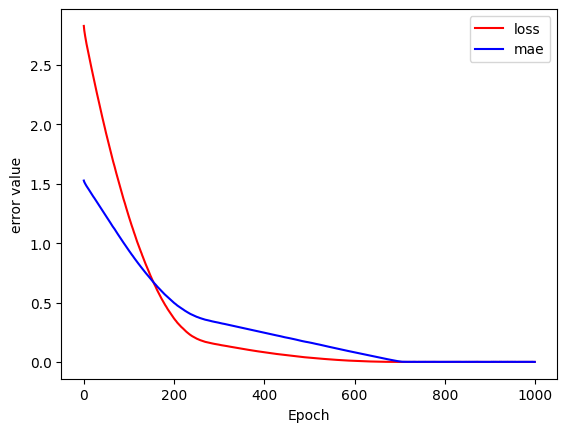

In [22]:
plt.plot(hist.history['loss'], 'r', label='loss')
plt.plot(hist.history['mae'], 'b', label='mae')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('error value')

In [25]:
# 모델 사용
model.predict(np.array([[0],
                       [0.01],
                       [0.02]]))

1/1 [==============================] - 0s 20ms/step


array([[0.32009548],
       [0.33809537],
       [0.35609525]], dtype=float32)

In [26]:
model.save('model/after_learning.h5')